In [6]:
import pandas as pd
import os

data_path = '/Users/saisharanbalagopal/Documents/manufacturing-analysis /data/'

dgorder = pd.read_csv(data_path + 'DGORDER.csv')
amtmno = pd.read_csv(data_path + 'AMTMNO.csv')
amtmvs = pd.read_csv(data_path + 'AMTMVS.csv')
amtmii = pd.read_csv(data_path + 'AMTMTI.csv')

datasets = {
    'Durable Goods Orders': dgorder,
    'Total Mfg New Orders': amtmno,
    'Total Mfg Shipments': amtmvs,
    'Total Mfg Inventories': amtmii
}

for name, df in datasets.items():
    print(f"--- {name} ---")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Date range: {df.iloc[0,0]} to {df.iloc[-1,0]}")
    print(f"Nulls: {df.isnull().sum().tolist()}")
    print()

--- Durable Goods Orders ---
Shape: (407, 2)
Columns: ['observation_date', 'DGORDER']
Date range: 1992-02-01 to 2025-12-01
Nulls: [0, 0]

--- Total Mfg New Orders ---
Shape: (407, 2)
Columns: ['observation_date', 'AMTMNO']
Date range: 1992-02-01 to 2025-12-01
Nulls: [0, 0]

--- Total Mfg Shipments ---
Shape: (408, 2)
Columns: ['observation_date', 'AMTMVS']
Date range: 1992-01-01 to 2025-12-01
Nulls: [0, 0]

--- Total Mfg Inventories ---
Shape: (408, 2)
Columns: ['observation_date', 'AMTMTI']
Date range: 1992-01-01 to 2025-12-01
Nulls: [0, 0]



In [3]:
import os
os.getcwd()

'/Users/saisharanbalagopal/Documents/manufacturing-analysis /notebooks'

In [5]:
import os
data_path = '/Users/saisharanbalagopal/Documents/manufacturing-analysis /data/'
print(os.listdir(data_path))

['DGORDER.csv', 'AMTMNO.csv', 'AMTMVS.csv', 'AMTMTI.csv']


In [7]:
# Merge all four into one dataframe
df = dgorder.copy()
df = df.merge(amtmno, on='observation_date')
df = df.merge(amtmvs, on='observation_date')
df = df.merge(amtmii, on='observation_date')

# Convert date column to datetime
df['observation_date'] = pd.to_datetime(df['observation_date'])

# Rename columns to something readable
df.columns = ['date', 'durable_goods_orders', 'total_mfg_orders', 
              'total_mfg_shipments', 'total_mfg_inventories']

# Quick look at what we have
print(f"Combined shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print()
print(df.head())
print()
print(df.describe().round(1))

Combined shape: (407, 5)
Date range: 1992-02-01 00:00:00 to 2025-12-01 00:00:00

        date  durable_goods_orders  total_mfg_orders  total_mfg_shipments  \
0 1992-02-01                114535            223500               228860   
1 1992-03-01                120025            233732               238604   
2 1992-04-01                124470            238173               239877   
3 1992-05-01                125822            241916               243732   
4 1992-06-01                122834            240660               245693   

   total_mfg_inventories  
0                 376757  
1                 377688  
2                 377491  
3                 377450  
4                 377055  

                                date  durable_goods_orders  total_mfg_orders  \
count                            407                 407.0             407.0   
mean   2008-12-30 22:31:32.874692864              207577.3          412956.6   
min              1992-02-01 00:00:00              114

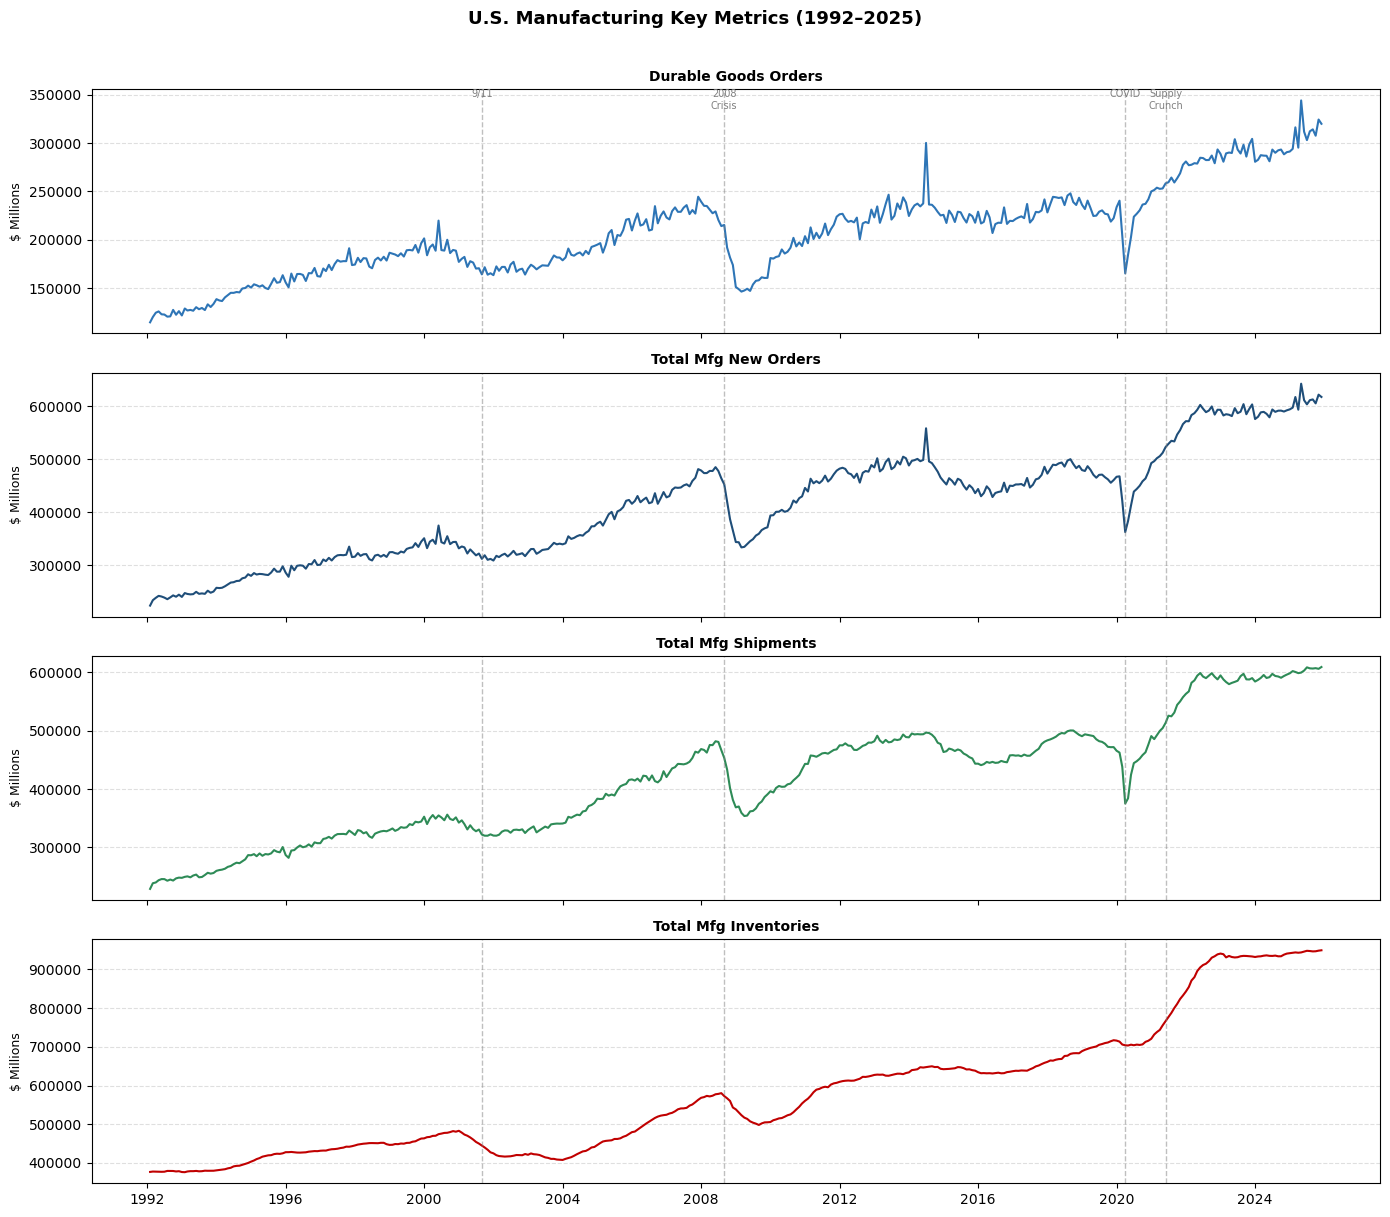

Chart saved.


In [11]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

series = [
    ('durable_goods_orders', 'Durable Goods Orders', '#2E75B6'),
    ('total_mfg_orders', 'Total Mfg New Orders', '#1F4E79'),
    ('total_mfg_shipments', 'Total Mfg Shipments', '#2E8B57'),
    ('total_mfg_inventories', 'Total Mfg Inventories', '#C00000'),
]

# Key events to annotate
events = {
    '2001-09-01': '9/11',
    '2008-09-01': '2008\nCrisis',
    '2020-04-01': 'COVID',
    '2021-06-01': 'Supply\nCrunch',
}

for ax, (col, title, color) in zip(axes, series):
    ax.plot(df['date'], df[col], color=color, linewidth=1.5)
    ax.set_ylabel('$ Millions', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add event markers
    for date_str, label in events.items():
        event_date = pd.to_datetime(date_str)
        ax.axvline(x=event_date, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        if ax == axes[0]:
            ax.text(event_date, ax.get_ylim()[1], label, 
                   fontsize=7, ha='center', va='top', color='gray')

axes[-1].xaxis.set_major_locator(mdates.YearLocator(4))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('U.S. Manufacturing Key Metrics (1992–2025)', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/01_time_series_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [12]:
# Calculate month-over-month % change for each series
df['dgo_mom'] = df['durable_goods_orders'].pct_change() * 100
df['orders_mom'] = df['total_mfg_orders'].pct_change() * 100
df['shipments_mom'] = df['total_mfg_shipments'].pct_change() * 100
df['inventories_mom'] = df['total_mfg_inventories'].pct_change() * 100

# Find the 5 worst months for durable goods orders
print("=== 5 Worst Months for Durable Goods Orders ===")
print(df[['date', 'durable_goods_orders', 'dgo_mom']]
      .nsmallest(5, 'dgo_mom')
      .round(1)
      .to_string(index=False))

print()

# Find the 5 worst months for total orders
print("=== 5 Worst Months for Total Mfg Orders ===")
print(df[['date', 'total_mfg_orders', 'orders_mom']]
      .nsmallest(5, 'orders_mom')
      .round(1)
      .to_string(index=False))

print()

# How long did COVID recovery take?
covid_low = df[df['date'] >= '2020-01-01']['durable_goods_orders'].idxmin()
pre_covid = df[df['date'] == '2020-01-01']['durable_goods_orders'].values[0]
recovery = df[(df['date'] > df.loc[covid_low, 'date']) & 
              (df['durable_goods_orders'] >= pre_covid)].iloc[0]

print("=== COVID Recovery ===")
print(f"Pre-COVID level (Jan 2020): ${pre_covid:,.0f}M")
print(f"COVID low point: {df.loc[covid_low, 'date'].strftime('%b %Y')} at ${df.loc[covid_low, 'durable_goods_orders']:,.0f}M")
print(f"Recovery back to pre-COVID: {recovery['date'].strftime('%b %Y')}")

=== 5 Worst Months for Durable Goods Orders ===
      date  durable_goods_orders  dgo_mom
2014-08-01                236400    -21.2
2020-04-01                165166    -19.3
2020-03-01                204710    -14.8
2000-07-01                189265    -13.9
2009-01-01                151085    -13.1

=== 5 Worst Months for Total Mfg Orders ===
      date  total_mfg_orders  orders_mom
2020-04-01            362308       -14.0
2014-08-01            495777       -11.2
2020-03-01            421299        -9.9
2000-07-01            343351        -8.4
2008-11-01            386733        -7.9

=== COVID Recovery ===
Pre-COVID level (Jan 2020): $233,656M
COVID low point: Apr 2020 at $165,166M
Recovery back to pre-COVID: Oct 2020


## Key Findings — Time Series Audit

**Data:** 4 FRED manufacturing series, Feb 1992 – Dec 2025, 407 monthly observations, zero nulls.

**Finding 1:** Durable goods orders are the most volatile indicator — they lead shipments 
and inventories, making them the best early warning signal for operational stress.

**Finding 2:** The 2008-09 financial crisis was the most severe shock in the dataset 
(-37.7% YoY in March 2009), significantly worse than COVID (-19.3% in April 2020).

**Finding 3:** COVID recovery was faster than expected — durable goods orders returned 
to pre-COVID levels within 6 months (April → October 2020).

**Finding 4:** August 2014 shows the largest single-month drop (-21.2%) without a 
corresponding recession — warrants further investigation.

**Next step:** Bring in BLS Producer Price Index data to test whether input cost 
increases lead or lag order volume changes.

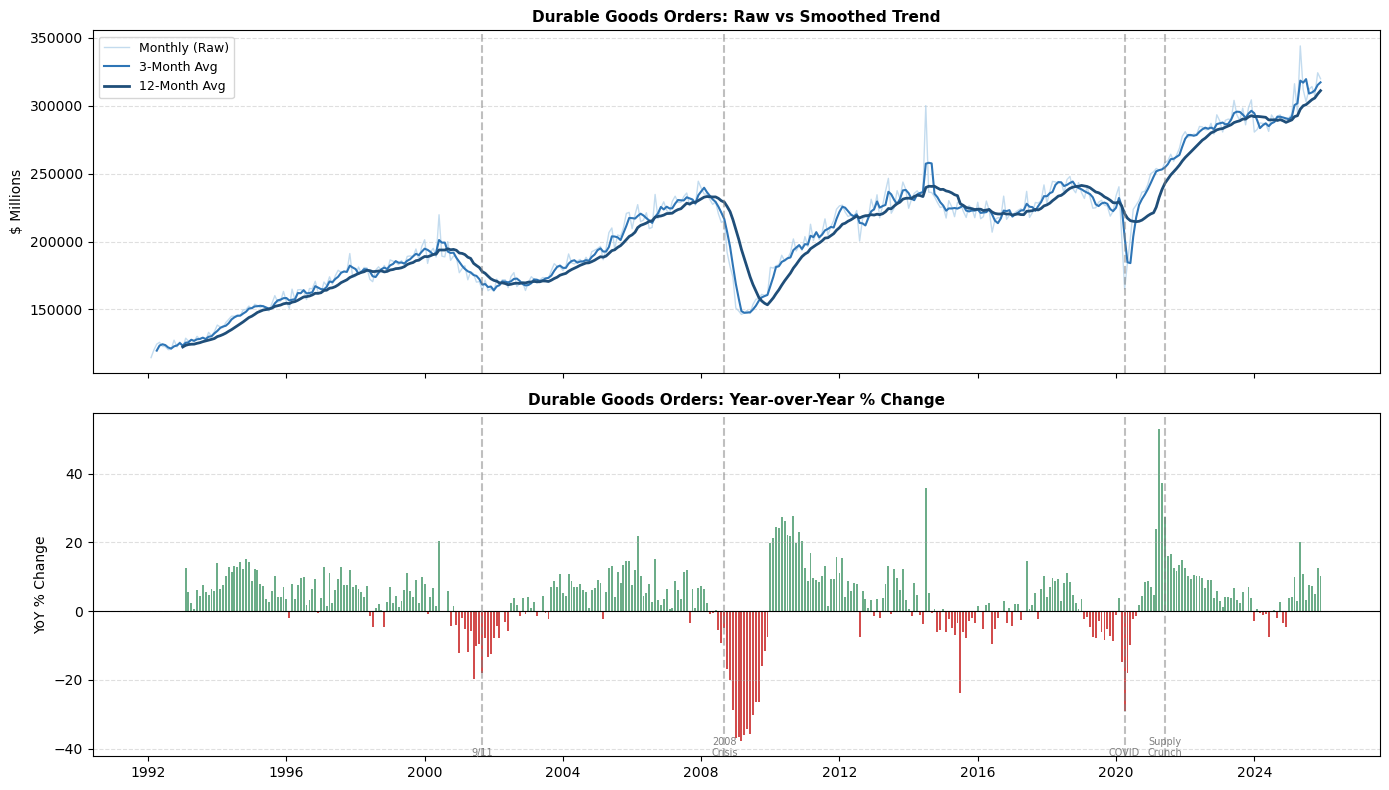

Chart saved.

=== Worst 5 Year-over-Year Periods (Durable Goods) ===
      date  dgo_yoy
2009-03-01    -37.7
2009-01-01    -36.9
2009-02-01    -36.7
2009-04-01    -36.2
2009-06-01    -35.9

=== Best 5 Year-over-Year Periods (Durable Goods) ===
      date  dgo_yoy
2021-04-01     52.9
2021-05-01     37.2
2014-07-01     35.9
2010-09-01     27.8
2021-06-01     27.4


In [13]:
# Year-over-year % change
df['dgo_yoy'] = df['durable_goods_orders'].pct_change(12) * 100
df['orders_yoy'] = df['total_mfg_orders'].pct_change(12) * 100
df['shipments_yoy'] = df['total_mfg_shipments'].pct_change(12) * 100

# 3-month and 12-month rolling average for durable goods orders
df['dgo_3m_avg'] = df['durable_goods_orders'].rolling(3).mean()
df['dgo_12m_avg'] = df['durable_goods_orders'].rolling(12).mean()

# Plot: raw vs smoothed + YoY
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top chart: raw vs rolling averages
ax1.plot(df['date'], df['durable_goods_orders'], 
         color='#AACDE8', linewidth=1, label='Monthly (Raw)', alpha=0.7)
ax1.plot(df['date'], df['dgo_3m_avg'], 
         color='#2E75B6', linewidth=1.5, label='3-Month Avg')
ax1.plot(df['date'], df['dgo_12m_avg'], 
         color='#1F4E79', linewidth=2, label='12-Month Avg')
ax1.set_title('Durable Goods Orders: Raw vs Smoothed Trend', 
              fontweight='bold', fontsize=11)
ax1.set_ylabel('$ Millions')
ax1.legend(fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Bottom chart: YoY % change
ax2.bar(df['date'], df['dgo_yoy'], 
        color=df['dgo_yoy'].apply(lambda x: '#2E8B57' if x >= 0 else '#C00000'),
        width=20, alpha=0.7)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_title('Durable Goods Orders: Year-over-Year % Change', 
              fontweight='bold', fontsize=11)
ax2.set_ylabel('YoY % Change')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

# Event lines on both
for date_str, label in events.items():
    event_date = pd.to_datetime(date_str)
    ax1.axvline(x=event_date, color='gray', linestyle='--', alpha=0.5)
    ax2.axvline(x=event_date, color='gray', linestyle='--', alpha=0.5)
    ax2.text(event_date, ax2.get_ylim()[0], label, 
             fontsize=7, ha='center', color='gray')

plt.tight_layout()
plt.savefig('../notebooks/02_trend_yoy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

# Print the worst YoY periods
print("\n=== Worst 5 Year-over-Year Periods (Durable Goods) ===")
print(df[['date', 'dgo_yoy']].nsmallest(5, 'dgo_yoy').round(1).to_string(index=False))

print("\n=== Best 5 Year-over-Year Periods (Durable Goods) ===")
print(df[['date', 'dgo_yoy']].nlargest(5, 'dgo_yoy').round(1).to_string(index=False))

In [14]:
df.to_csv('../data/manufacturing_combined.csv', index=False)
print("Combined dataset saved.")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Combined dataset saved.
Shape: (407, 14)
Columns: ['date', 'durable_goods_orders', 'total_mfg_orders', 'total_mfg_shipments', 'total_mfg_inventories', 'dgo_mom', 'orders_mom', 'shipments_mom', 'inventories_mom', 'dgo_yoy', 'orders_yoy', 'shipments_yoy', 'dgo_3m_avg', 'dgo_12m_avg']


In [15]:
# Load PPI data
ppi = pd.read_csv('../data/PPIACO.csv')
ppi.columns = ['date', 'ppi']
ppi['date'] = pd.to_datetime(ppi['date'])

# Trim to match our dataset start date
ppi = ppi[ppi['date'] >= '1992-02-01'].reset_index(drop=True)

# Quick audit
print(f"Shape: {ppi.shape}")
print(f"Date range: {ppi['date'].min()} to {ppi['date'].max()}")
print(f"Nulls: {ppi.isnull().sum().tolist()}")
print()
print(ppi.head())

Shape: (408, 2)
Date range: 1992-02-01 00:00:00 to 2026-01-01 00:00:00
Nulls: [0, 0]

        date    ppi
0 1992-02-01  116.0
1 1992-03-01  116.1
2 1992-04-01  116.3
3 1992-05-01  117.2
4 1992-06-01  118.0


Combined shape: (407, 15)
Date range: 1992-02-01 00:00:00 to 2025-12-01 00:00:00



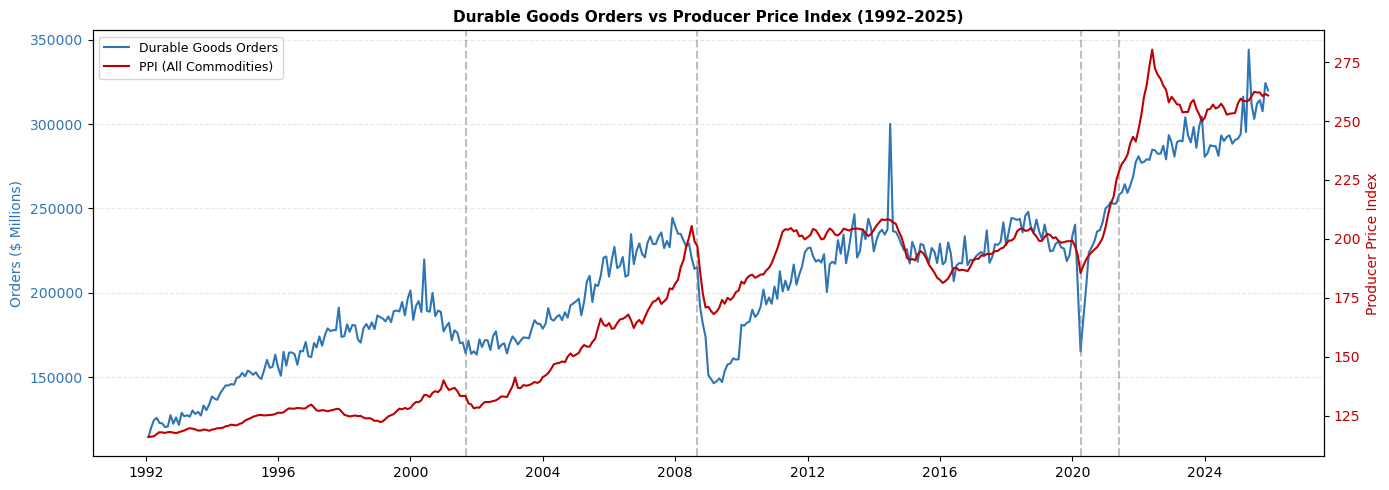

Chart saved.


In [16]:
# Merge PPI with our combined manufacturing dataframe
df_full = df.merge(ppi, on='date', how='inner')

print(f"Combined shape: {df_full.shape}")
print(f"Date range: {df_full['date'].min()} to {df_full['date'].max()}")
print()

# Now plot PPI against Durable Goods Orders on same chart
fig, ax1 = plt.subplots(figsize=(14, 5))

# Durable goods orders on left axis
ax1.plot(df_full['date'], df_full['durable_goods_orders'], 
         color='#2E75B6', linewidth=1.5, label='Durable Goods Orders')
ax1.set_ylabel('Orders ($ Millions)', color='#2E75B6', fontsize=10)
ax1.tick_params(axis='y', labelcolor='#2E75B6')

# PPI on right axis
ax2 = ax1.twinx()
ax2.plot(df_full['date'], df_full['ppi'], 
         color='#C00000', linewidth=1.5, label='PPI (All Commodities)')
ax2.set_ylabel('Producer Price Index', color='#C00000', fontsize=10)
ax2.tick_params(axis='y', labelcolor='#C00000')

# Event lines
for date_str, label in events.items():
    event_date = pd.to_datetime(date_str)
    ax1.axvline(x=event_date, color='gray', linestyle='--', alpha=0.5)

ax1.set_title('Durable Goods Orders vs Producer Price Index (1992–2025)', 
              fontweight='bold', fontsize=11)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('../notebooks/03_orders_vs_ppi.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [19]:
import scipy
print(scipy.__version__)

1.16.3


## Key Finding — Lag Correlation Analysis

**Question:** Does PPI lead manufacturing orders, or do orders lead PPI?

**Answer:** Orders lead PPI by approximately 2 months (r = 0.58, p < 0.0001).

**Business implication:** Procurement teams using PPI as a leading indicator 
are already 2 months behind the signal. Monitoring durable goods order volumes 
provides earlier warning of input cost changes, enabling faster procurement 
and inventory adjustments.

**Next step:** Build the inventory stress indicator — 
orders-to-inventory ratio over time.

In [18]:
from scipy import stats

# Create clean YoY columns with no nulls
df_full['ppi_yoy'] = df_full['ppi'].pct_change(12) * 100
df_full['dgo_yoy'] = df_full['durable_goods_orders'].pct_change(12) * 100

# Drop nulls and reset index
analysis = df_full[['date', 'ppi_yoy', 'dgo_yoy']].dropna().reset_index(drop=True)

print(f"Rows available for correlation analysis: {len(analysis)}")
print()
print("=== Correlation: PPI YoY vs Durable Goods Orders YoY ===")
print()

for lag in range(-6, 7):
    ppi_series = analysis['ppi_yoy'].iloc[:len(analysis)-abs(lag)] if lag > 0 else analysis['ppi_yoy'].iloc[abs(lag):]
    dgo_series = analysis['dgo_yoy'].iloc[lag:] if lag > 0 else analysis['dgo_yoy'].iloc[:len(analysis)-abs(lag)]
    
    ppi_series = ppi_series.reset_index(drop=True)
    dgo_series = dgo_series.reset_index(drop=True)
    
    corr, pval = stats.pearsonr(ppi_series, dgo_series)
    
    if lag > 0:
        label = f"PPI leads orders by {lag} months"
    elif lag < 0:
        label = f"Orders lead PPI by {abs(lag)} months"
    else:
        label = "Same month (no lag)"
    
    print(f"Lag {lag:+d} | r = {corr:.3f} | p = {pval:.4f} | {label}")

=== Correlation: PPI YoY vs Durable Goods Orders YoY ===
(How much does PPI today correlate with orders N months later?)

Lag -6 | Correlation: 0.490 | p-value: 0.0000 | Orders lead PPI by 6 months
Lag -5 | Correlation: 0.529 | p-value: 0.0000 | Orders lead PPI by 5 months
Lag -4 | Correlation: 0.556 | p-value: 0.0000 | Orders lead PPI by 4 months
Lag -3 | Correlation: 0.574 | p-value: 0.0000 | Orders lead PPI by 3 months
Lag -2 | Correlation: 0.580 | p-value: 0.0000 | Orders lead PPI by 2 months
Lag -1 | Correlation: 0.572 | p-value: 0.0000 | Orders lead PPI by 1 months
Lag +0 | Correlation: 0.550 | p-value: 0.0000 | Same month (no lag)
Lag +1 | Correlation: 0.510 | p-value: 0.0000 | PPI leads orders by 1 months
Lag +2 | Correlation: 0.447 | p-value: 0.0000 | PPI leads orders by 2 months
Lag +3 | Correlation: 0.367 | p-value: 0.0000 | PPI leads orders by 3 months
Lag +4 | Correlation: 0.279 | p-value: 0.0000 | PPI leads orders by 4 months
Lag +5 | Correlation: 0.195 | p-value: 0.0001 

## Key Finding — Inventory Stress Indicator

**Metric:** Orders-to-Inventory Ratio (total manufacturing orders / total inventories)
**Historical average:** 0.724

**Boom period:** Oct 2005 – Mar 2006 (ratio peaked at 0.896)
- Orders significantly outpacing inventory — classic demand surge

**Stress period:** Mar 2020 – Dec 2025 (70 consecutive months below average)
- Longest sustained stress period in the 33-year dataset
- COVID was the trigger but the stress persisted long after recovery

**Business implication:** This is not a cyclical pattern — 70 months of 
below-average ratio suggests a structural inventory overhang that procurement 
and operations teams should be actively managing, not waiting out.

=== Orders-to-Inventory Ratio Summary ===
Average ratio (full period): 0.724
Highest ratio (most stressed): 0.896 on Nov 2005
Lowest ratio (least stressed): 0.515 on Apr 2020



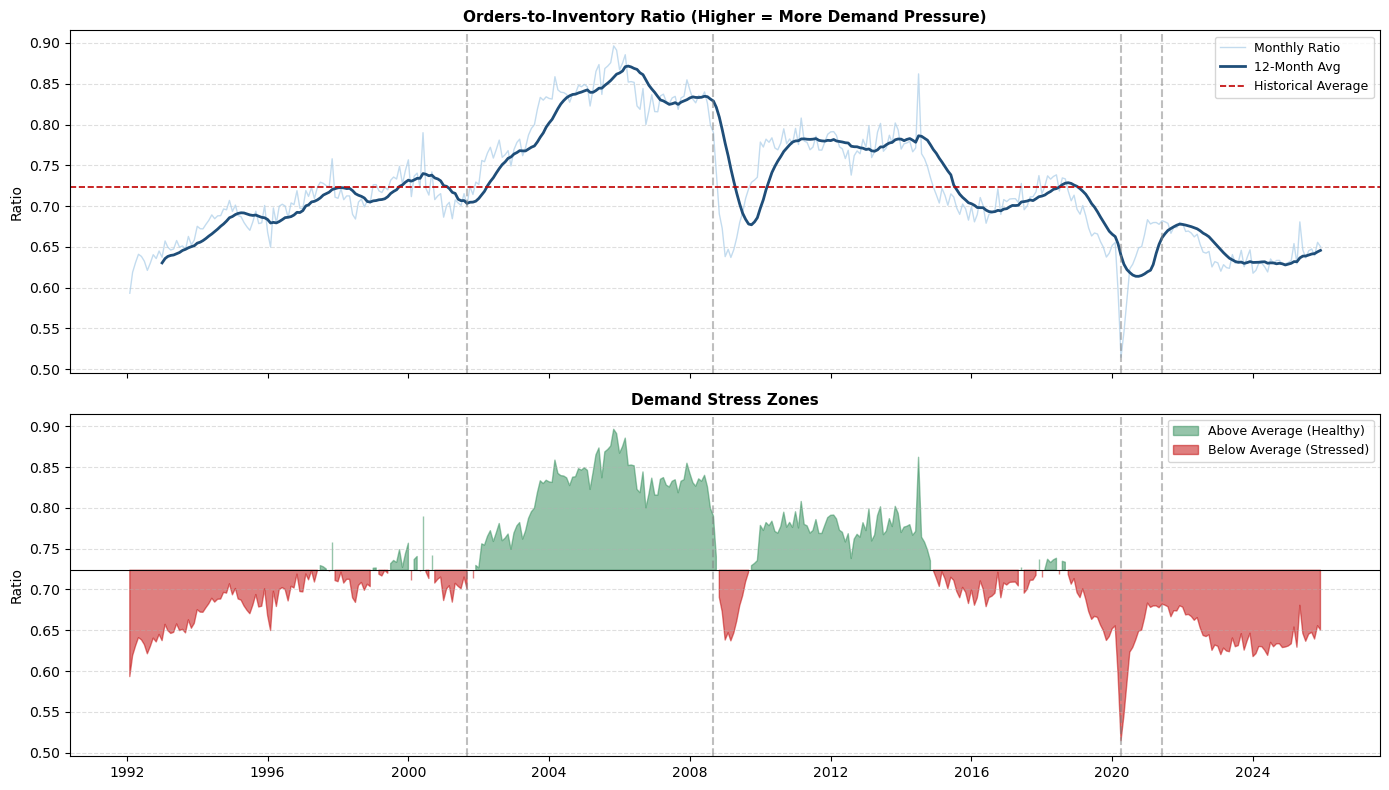

Chart saved.


In [20]:
# Orders to Inventory Ratio
df_full['orders_to_inventory'] = (df_full['total_mfg_orders'] / 
                                   df_full['total_mfg_inventories'])

# 12 month rolling average of the ratio
df_full['oti_12m_avg'] = df_full['orders_to_inventory'].rolling(12).mean()

# Summary stats
print("=== Orders-to-Inventory Ratio Summary ===")
print(f"Average ratio (full period): {df_full['orders_to_inventory'].mean():.3f}")
print(f"Highest ratio (most stressed): {df_full['orders_to_inventory'].max():.3f} on {df_full.loc[df_full['orders_to_inventory'].idxmax(), 'date'].strftime('%b %Y')}")
print(f"Lowest ratio (least stressed): {df_full['orders_to_inventory'].min():.3f} on {df_full.loc[df_full['orders_to_inventory'].idxmin(), 'date'].strftime('%b %Y')}")
print()

# Plot it
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: raw ratio vs rolling average
ax1.plot(df_full['date'], df_full['orders_to_inventory'],
         color='#AACDE8', linewidth=1, alpha=0.7, label='Monthly Ratio')
ax1.plot(df_full['date'], df_full['oti_12m_avg'],
         color='#1F4E79', linewidth=2, label='12-Month Avg')
ax1.axhline(y=df_full['orders_to_inventory'].mean(), 
            color='#C00000', linewidth=1.2, linestyle='--', label='Historical Average')
ax1.set_title('Orders-to-Inventory Ratio (Higher = More Demand Pressure)', 
              fontweight='bold', fontsize=11)
ax1.set_ylabel('Ratio')
ax1.legend(fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Bottom: shade zones above/below average
ratio_mean = df_full['orders_to_inventory'].mean()
ax2.fill_between(df_full['date'], df_full['orders_to_inventory'], ratio_mean,
                 where=(df_full['orders_to_inventory'] >= ratio_mean),
                 color='#2E8B57', alpha=0.5, label='Above Average (Healthy)')
ax2.fill_between(df_full['date'], df_full['orders_to_inventory'], ratio_mean,
                 where=(df_full['orders_to_inventory'] < ratio_mean),
                 color='#C00000', alpha=0.5, label='Below Average (Stressed)')
ax2.axhline(y=ratio_mean, color='black', linewidth=0.8)
ax2.set_title('Demand Stress Zones', fontweight='bold', fontsize=11)
ax2.set_ylabel('Ratio')
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

for date_str, label in events.items():
    event_date = pd.to_datetime(date_str)
    ax1.axvline(x=event_date, color='gray', linestyle='--', alpha=0.5)
    ax2.axvline(x=event_date, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../notebooks/04_inventory_stress.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [21]:
print("=== Orders-to-Inventory Ratio — Corrected Interpretation ===")
print(f"Historical average: {df_full['orders_to_inventory'].mean():.3f}")
print()
print("--- Demand BOOM periods (ratio highest = orders outpacing inventory) ---")
print(df_full[['date', 'orders_to_inventory']]
      .nlargest(5, 'orders_to_inventory')
      .round(3)
      .to_string(index=False))
print()
print("--- Demand STRESS periods (ratio lowest = inventory piling up) ---")
print(df_full[['date', 'orders_to_inventory']]
      .nsmallest(5, 'orders_to_inventory')
      .round(3)
      .to_string(index=False))
print()

# How many months below average after COVID?
post_covid = df_full[df_full['date'] >= '2020-03-01'].copy()
stressed_months = post_covid[post_covid['orders_to_inventory'] < 
                              df_full['orders_to_inventory'].mean()]
print(f"Months below average ratio after March 2020: {len(stressed_months)}")
print(f"Stress period ended: {stressed_months['date'].max().strftime('%b %Y')}")

=== Orders-to-Inventory Ratio — Corrected Interpretation ===
Historical average: 0.724

--- Demand BOOM periods (ratio highest = orders outpacing inventory) ---
      date  orders_to_inventory
2005-11-01                0.896
2005-12-01                0.891
2006-03-01                0.886
2005-10-01                0.876
2006-02-01                0.875

--- Demand STRESS periods (ratio lowest = inventory piling up) ---
      date  orders_to_inventory
2020-04-01                0.515
2020-05-01                0.545
2020-06-01                0.585
1992-02-01                0.593
2020-03-01                0.597

Months below average ratio after March 2020: 70
Stress period ended: Dec 2025


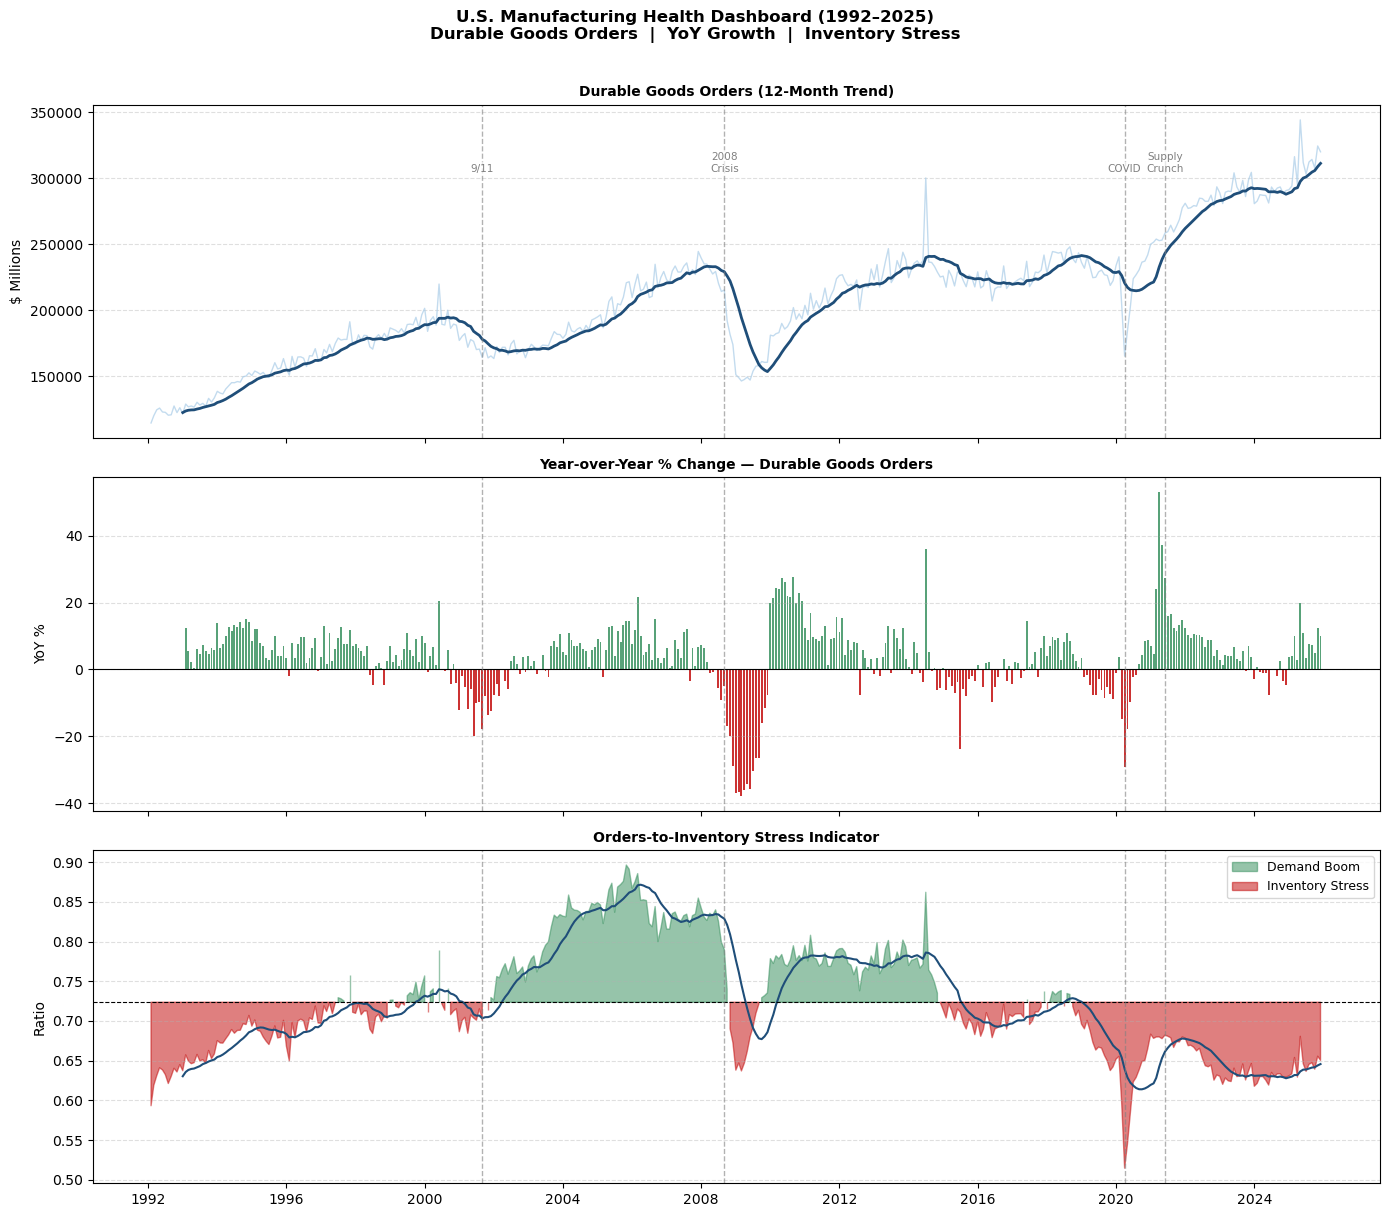

Summary dashboard saved.


In [22]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# --- Chart 1: Durable Goods Orders with 12m average ---
axes[0].plot(df_full['date'], df_full['durable_goods_orders'],
             color='#AACDE8', linewidth=1, alpha=0.7)
axes[0].plot(df_full['date'], df_full['dgo_12m_avg'],
             color='#1F4E79', linewidth=2)
axes[0].set_title('Durable Goods Orders (12-Month Trend)', 
                  fontweight='bold', fontsize=10)
axes[0].set_ylabel('$ Millions')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# --- Chart 2: YoY % Change with color coding ---
colors = df_full['dgo_yoy'].apply(lambda x: '#2E8B57' if x >= 0 else '#C00000')
axes[1].bar(df_full['date'], df_full['dgo_yoy'], 
            color=colors, width=20, alpha=0.8)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_title('Year-over-Year % Change — Durable Goods Orders', 
                  fontweight='bold', fontsize=10)
axes[1].set_ylabel('YoY %')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# --- Chart 3: Inventory stress ratio ---
ratio_mean = df_full['orders_to_inventory'].mean()
axes[2].fill_between(df_full['date'], df_full['orders_to_inventory'], ratio_mean,
                     where=(df_full['orders_to_inventory'] >= ratio_mean),
                     color='#2E8B57', alpha=0.5, label='Demand Boom')
axes[2].fill_between(df_full['date'], df_full['orders_to_inventory'], ratio_mean,
                     where=(df_full['orders_to_inventory'] < ratio_mean),
                     color='#C00000', alpha=0.5, label='Inventory Stress')
axes[2].plot(df_full['date'], df_full['oti_12m_avg'],
             color='#1F4E79', linewidth=1.5)
axes[2].axhline(y=ratio_mean, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Orders-to-Inventory Stress Indicator', 
                  fontweight='bold', fontsize=10)
axes[2].set_ylabel('Ratio')
axes[2].legend(fontsize=9)
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

# Event lines and annotations on all charts
event_labels = {
    '2001-09-01': '9/11',
    '2008-09-01': '2008\nCrisis',
    '2020-04-01': 'COVID',
    '2021-06-01': 'Supply\nCrunch'
}

for date_str, label in event_labels.items():
    event_date = pd.to_datetime(date_str)
    for ax in axes:
        ax.axvline(x=event_date, color='gray', linestyle='--', 
                   alpha=0.6, linewidth=1)
    axes[0].text(event_date, df_full['dgo_12m_avg'].max() * 0.98,
                label, fontsize=7.5, ha='center', color='gray',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                         alpha=0.7, edgecolor='none'))

plt.suptitle('U.S. Manufacturing Health Dashboard (1992–2025)\n'
             'Durable Goods Orders  |  YoY Growth  |  Inventory Stress',
             fontsize=12, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('../notebooks/05_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary dashboard saved.")

In [23]:
# Select and rename columns for Tableau
tableau_export = df_full[[
    'date',
    'durable_goods_orders',
    'total_mfg_orders',
    'total_mfg_shipments',
    'total_mfg_inventories',
    'ppi',
    'dgo_yoy',
    'orders_yoy',
    'shipments_yoy',
    'ppi_yoy',
    'orders_to_inventory',
    'oti_12m_avg',
    'dgo_12m_avg'
]].copy()

# Round all numeric columns to 2 decimal places
numeric_cols = tableau_export.columns.drop('date')
tableau_export[numeric_cols] = tableau_export[numeric_cols].round(2)

# Add a recession/shock flag column — useful for Tableau filters
def label_period(date):
    if pd.Timestamp('2001-03-01') <= date <= pd.Timestamp('2001-11-01'):
        return '2001 Recession'
    elif pd.Timestamp('2007-12-01') <= date <= pd.Timestamp('2009-06-01'):
        return '2008 Financial Crisis'
    elif pd.Timestamp('2020-02-01') <= date <= pd.Timestamp('2020-10-01'):
        return 'COVID-19'
    elif pd.Timestamp('2021-01-01') <= date <= pd.Timestamp('2022-06-01'):
        return 'Supply Chain Crunch'
    else:
        return 'Normal'

tableau_export['period_label'] = tableau_export['date'].apply(label_period)

# Save
tableau_export.to_csv('../data/manufacturing_tableau.csv', index=False)

print(f"Tableau export saved.")
print(f"Shape: {tableau_export.shape}")
print(f"Columns: {tableau_export.columns.tolist()}")
print()
print("Period distribution:")
print(tableau_export['period_label'].value_counts())

Tableau export saved.
Shape: (407, 14)
Columns: ['date', 'durable_goods_orders', 'total_mfg_orders', 'total_mfg_shipments', 'total_mfg_inventories', 'ppi', 'dgo_yoy', 'orders_yoy', 'shipments_yoy', 'ppi_yoy', 'orders_to_inventory', 'oti_12m_avg', 'dgo_12m_avg', 'period_label']

Period distribution:
period_label
Normal                   352
2008 Financial Crisis     19
Supply Chain Crunch       18
2001 Recession             9
COVID-19                   9
Name: count, dtype: int64


## Notebook Complete — Data Export Summary

**Output file:** `manufacturing_tableau.csv`  
**Rows:** 407 months (Feb 1992 – Dec 2025)  
**Columns:** 14 (raw series, derived metrics, period labels)

### Three Core Findings for Business Brief:

**Finding 1 — Volatility Signal:**
Durable goods orders are the most sensitive leading indicator in the dataset.
The 2008 crisis caused a -37.7% YoY decline, nearly double the COVID drop of -19.3%.

**Finding 2 — Lag Relationship:**
Orders lead PPI by 2 months (r=0.58, p<0.0001). Procurement teams 
watching PPI as a leading indicator are systematically 2 months behind the signal.

**Finding 3 — Structural Stress:**
70 consecutive months below the historical orders-to-inventory average 
(Mar 2020 – Dec 2025) suggests a structural inventory overhang, 
not a cyclical dip.

### Charts Produced:
- 01_time_series_overview.png
- 02_trend_yoy.png  
- 03_orders_vs_ppi.png
- 04_inventory_stress.png
- 05_summary_dashboard.png